# ESAME

### INTRODUZIONE

# Analisi Statistica dei Dati: Conteggi di un Contatore Geiger

Lo scopo di questa prova è analizzare l'aspetto probabilistico dei dati raccolti tramite un contatore Geiger. L'analisi si articola in tre fasi principali: lo studio dei tempi di attesa tra eventi, l'analisi del numero di conteggi in finestre temporali fisse e, infine, il test di validità dei modelli probabilistici utilizzati.

---

## 1. Analisi dei Tempi di Attesa

Per prima cosa, visualizziamo l'istogramma dei conteggi ottenuti e stimiamo il parametro del tempo di attesa medio ($\tau$) tramite il metodo della **Maximum Likelihood (Unbinned)** applicato alla distribuzione esponenziale, la quale descrive la densità di probabilità di osservare il prossimo evento al tempo $t$.

Successivamente, ci concentriamo sull'analisi dei tempi di attesa necessari per osservare **due eventi consecutivi**. In questo caso, il modello probabilistico corretto è la **distribuzione di Erlang con $k=2$**. 

Per la stima del parametro $\lambda$ (e conseguentemente $\tau = 1/\lambda$), preferiamo passare a metodi applicati ai dati raggruppati (binned), molto utili quando si ha a che fare con set di dati numerosi rappresentati in istogrammi. Utilizziamo due approcci visti a lezione:

* **Binned Maximum Likelihood:** Raggruppando i dati in un istogramma, la distribuzione dei conteggi nei diversi bin segue una statistica multinomiale, la quale dipende implicitamente da $\tau$ (poiché il numero di conteggi atteso in un dato bin varia al variare del parametro). Per valutarne l'incertezza, utilizziamo un metodo grafico basato sull'espansione in serie di Taylor del logaritmo della likelihood $\ln\mathcal{L}_B(\lambda)$ attorno al suo valore di massimo (MLE).
* **Binned Chi-Squared:** Sapendo che, quando il numero di eventi attesi in un bin è sufficientemente grande (tipicamente $\ge 5$), la distribuzione di Poisson che modella i conteggi del singolo bin è ben approssimata da una Gaussiana. Il modello teorico per il numero di eventi attesi nell'$i$-esimo bin è dato da $\nu_i = N \cdot P(x_i, \lambda) \cdot \Delta x$, dove $P(x_i, \lambda)$ è la densità di probabilità (nel nostro caso di Erlang) valutata al centro del bin, $N$ è il numero di eventi totale e $\Delta x$ è la larghezza del bin. Minimizzando il $\chi^2$, otteniamo la stima di $\lambda$.

---

## 2. Analisi dei Conteggi in Intervalli Temporali

Nella seconda parte dell'analisi, cambiamo variabile aleatoria: ci concentriamo sulla probabilità di osservare un certo numero $n$ di conteggi in una finestra temporale fissa $\Delta t = 30\text{ s}$. 

Il modello teorico di riferimento è in questo caso la **distribuzione di Poisson**. Seguendo lo stesso iter procedurale del punto precedente, applicheremo i metodi della **Binned Maximum Likelihood** e del **Binned Chi-Squared** per stimare il parametro atteso della poissoniana.

---

## 3. Test di Bontà dell'Adattamento (Goodness-of-Fit)

In ultima analisi, vogliamo verificare rigorosamente se i modelli probabilistici scelti descrivano adeguatamente i nostri dati sperimentali. Per farlo, utilizziamo il **Test del $\chi^2$ di Pearson**. 

L'ipotesi nulla ($H_0$) del nostro test è che i dati seguano effettivamente il modello proposto (Erlang o Poisson). Fissando un livello di significatività $\alpha = 0.05$ — ovvero accettando un rischio del 5% di rigettare il modello pur essendo questo corretto — valuteremo il risultato in due modi equivalenti:

1.  **Confronto diretto con il valore di soglia:** Calcoliamo il $\chi^2$ dai nostri dati e lo confrontiamo con il $\chi^2_{soglia}$. Dal punto di vista teorico, il valore di soglia si ottiene calcolando l'integrale della distribuzione di probabilità del $\chi^2$ (con $\nu$ gradi di libertà pari a *numero bin* - *parametri stimati* - 1) da un certo valore $x$ a $+\infty$, ponendo questo integrale pari ad $\alpha$. 
    * **Regola di decisione:** Non rigettiamo l'ipotesi (il modello va bene) se $\chi^2_{calcolato} < \chi^2_{soglia}$.
2.  **Calcolo del p-value:**
    Otteniamo il p-value corrispondente al nostro $\chi^2_{calcolato}$. Questo valore rappresenta la probabilità di ottenere un disaccordo tra dati e modello pari o superiore a quello osservato, supponendo che il modello sia esatto.
    * **Regola di decisione:** Rigettiamo l'ipotesi se il $p\text{-value} < \alpha$. Al contrario, se il $p\text{-value} \ge \alpha$, non abbiamo evidenze sufficienti per scartare il modello e quindi lo consideriamo un buon fit per i nostri dati.

### LIBRERIE NECESSARIE

In [71]:
import numpy as np
from scipy.special import factorial
import math
import matplotlib.pyplot as plt
from scipy.stats import chi2
from scipy.optimize import curve_fit
from IPython.display import display, Math

### DEFINIZIONE DELLE FUNZIONI

In [72]:
def Erlang_pdf(t, k, lam):
        return (lam**k * t**(k-1) * np.exp(-lam*t)) / math.factorial(k-1)

In [73]:
def Poisson_pdf(lam, k):
    return (lam**k / factorial(k)) * np.exp(-lam)

In [74]:
def log_likelihood_binned(n, centri, lam):
    return np.sum(n * np.log(Erlang_pdf(centri, 2, lam)))

In [75]:
def log_likelihood_binned2(n, k, lam):
    return np.sum(n * np.log(Poisson_pdf(lam, k)))

In [76]:
def chi_squared_binned2(n, N, lam, k, delta_x):
    return np.sum((n - delta_x*N*Poisson_pdf(lam,k))**2 / n)

In [77]:
def chi_squared_binned(n, centri, N, lam, delta_x):
    return np.sum((n - delta_x*N*Erlang_pdf(centri, 2, lam))**2 / n)

In [78]:
def chi_squared_binned_erlang(n, centri, N, lam, delta_x):
    return np.sum((n - delta_x*N*Erlang_pdf(centri, 2, lam))**2 / (delta_x*N*Erlang_pdf(centri, 2, lam)))

In [79]:
def chi_squared_binned_poisson(n, N, lam, k, delta_x):
    return np.sum((n - delta_x*N*Poisson_pdf(lam,k))**2 / (delta_x*N*Poisson_pdf(lam,k)))

In [80]:
def chi_squared(y, f, sigma): 
    return np.sum((y - f)**2 / sigma**2)

### ISTOGRAMMA DEI CONTEGGI

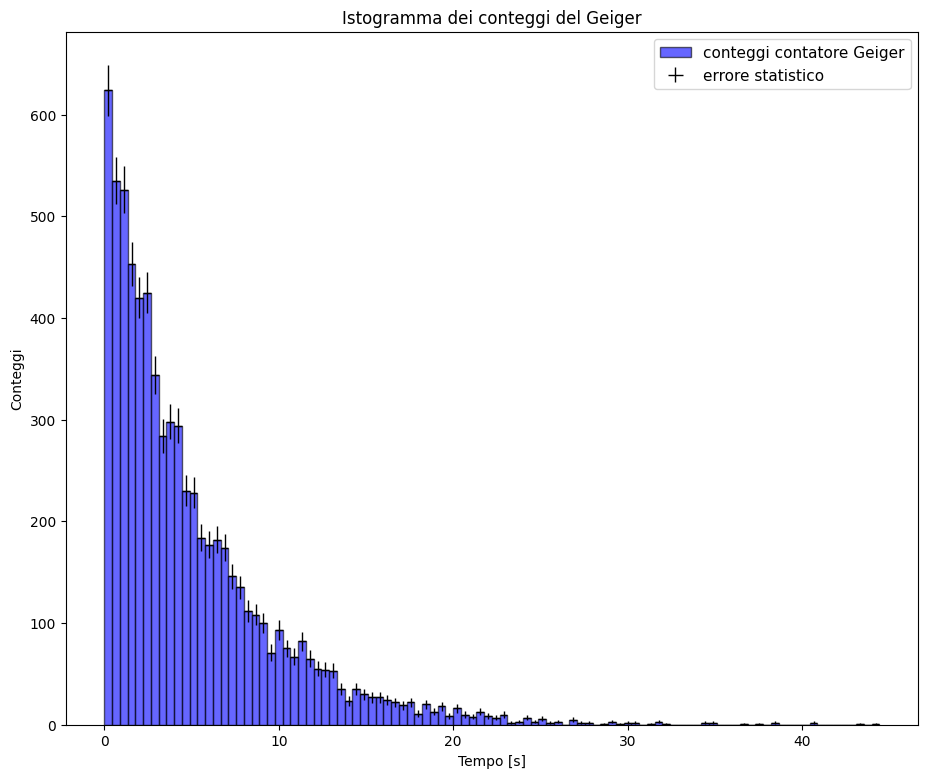

In [81]:
dati = np.loadtxt("conteggi_geiger_terraEtna_notte.txt")
dati = dati/1000

plt.figure(figsize=(11,9))
h, bins, patches = plt.hist(dati, bins=100, alpha=0.6, color='blue', edgecolor = 'black', label = "conteggi contatore Geiger")
larghezza_bin= bins[1]-bins[0]
centri_bin= bins[:-1] + larghezza_bin/2
plt.errorbar(centri_bin, h, np.sqrt(h), larghezza_bin/2, c='tab:grey', lw=1, fmt='none', ecolor='black', label="errore statistico")
plt.xlabel("Tempo [s]")
plt.ylabel("Conteggi")
plt.title(f"Istogramma dei conteggi del Geiger")
plt.legend(loc='best', prop={'size': 11})
plt.show()    

In [82]:
tau_hat= sum(dati)/len(dati)
display(Math(rf"\hat{{\tau}}_{{\mathcal{{L}}}} = {tau_hat} \, s"))
varianza_tau_hat = tau_hat**2/len(dati)
display(Math(rf"\sigma^2_{{\hat{{\tau}}_\mathcal{{L}}}} = {varianza_tau_hat} \,s^2"))
display(Math(rf"\text{{risultato finale}} \hspace{{0.5em}} \hat{{\tau}}_{{\mathcal{{L}}}}  = ({tau_hat:.2f} \pm {np.sqrt(varianza_tau_hat):.2f}) \, s"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### DISTRIBUZIONE DI ERLANG: TEMPO DI ATTESA FRA 2 EVENTI

In [83]:
#valori di indici pari
pari = dati[::2]
#valori di indici dispari
dispari = dati[1::2]
#sommo i dispari ai pari
#nel caso l'array dei pari sia più lungo di quello dei dipari ignoro l'ultimo pari
if(len(pari)>len(dispari)):
    pari = pari[:-1]
risultato = pari+dispari

<IPython.core.display.Math object>

Text(0.5, 1.0, 'Istogramma con curva di distribuzione Erlang')

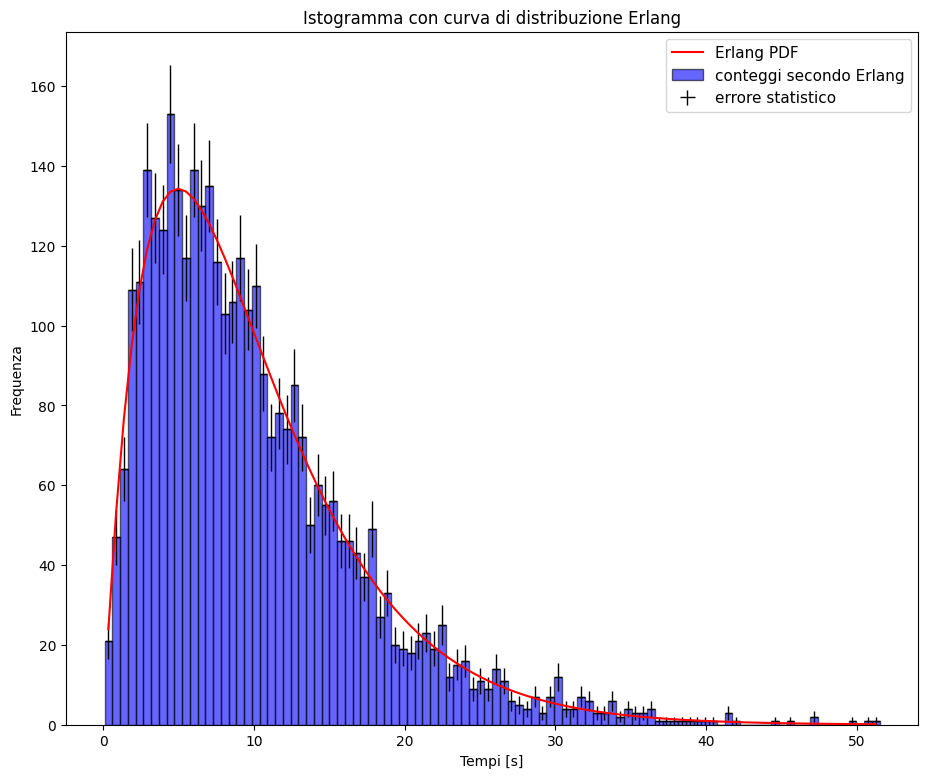

In [84]:
lam = 1/tau_hat
varianza_lam = varianza_tau_hat/(tau_hat**4)
display(Math(rf"\text{{risultato finale  }} \hat{{\lambda}}_{{\mathcal{{L}}}} = ({lam:.3f} \pm {np.sqrt(varianza_lam):.3f}) \, s^{{-1}}"))
plt.figure(figsize=(11,9))
h2, bin_edges = np.histogram(risultato, bins=100)
delta_x2 = bin_edges[1] - bin_edges[0]
centri2 = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri2, h2, width=delta_x2, color='blue',  alpha=0.6, edgecolor = 'black', label = 'conteggi secondo Erlang')
plt.errorbar(centri2, h2, yerr=np.sqrt(h2), xerr=delta_x2/2, fmt='none',  ecolor='black', lw=1, label='errore statistico')
plt.plot(centri2, Erlang_pdf(centri2, 2, lam) *len(risultato)*delta_x2 ,color='red', label='Erlang PDF')
plt.legend(loc='best', prop={'size': 11})
plt.xlabel('Tempi [s]')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva di distribuzione Erlang')

Text(0.5, 1.0, 'Log-likelihood in funzione di lambda')

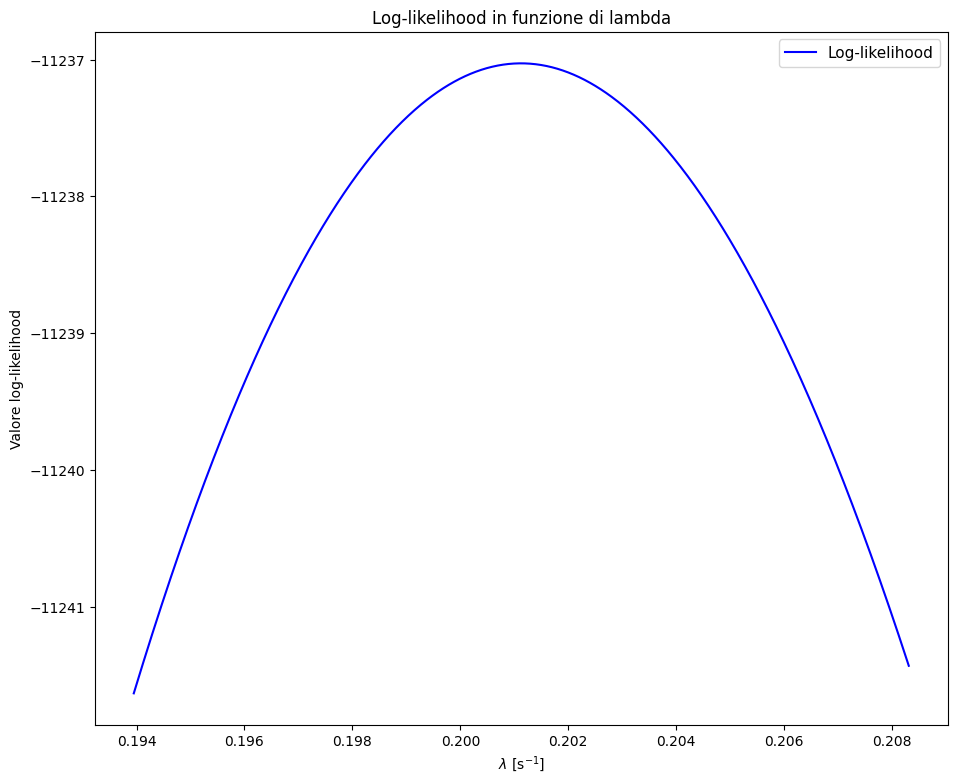

In [85]:
valori_lam = np.linspace(lam-3*np.sqrt(varianza_lam), lam + 3*np.sqrt(varianza_lam), 1000)
val_log_likelihood = [log_likelihood_binned(h2, centri2, lam) for lam in valori_lam]
plt.figure(figsize=(11,9))
plt.plot(valori_lam, val_log_likelihood, color='blue', label='Log-likelihood')
plt.xlabel(r'$\lambda$ [s$^{-1}$]')
plt.ylabel('Valore log-likelihood')
plt.legend(loc='best', prop={'size': 11})
plt.title(f'Log-likelihood in funzione di lambda')

In [86]:
for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        display(
            Math(
            rf"\lambda \hspace{{0.5em}} \text{{che massimizza}} \ln(\mathcal{{L}}) : {valori_lam[i]:.4f} \, s^{{-1}} \text{{ con valore }} \ln(\mathcal{{L}})_{{\text{{max}}}} = {val_log_likelihood[i]:.4f}"
            )
        )
        break
    else:
        continue

<IPython.core.display.Math object>

In [87]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        display(
            Math(
                rf"\text{{valori }} \lambda \text{{ vicino a}} \ln(\mathcal{{L}}(\lambda)) - \frac{{1}}{{2}} = {valori_lam[i]:.5f} \, s^{{-1}}"
            )
        )
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

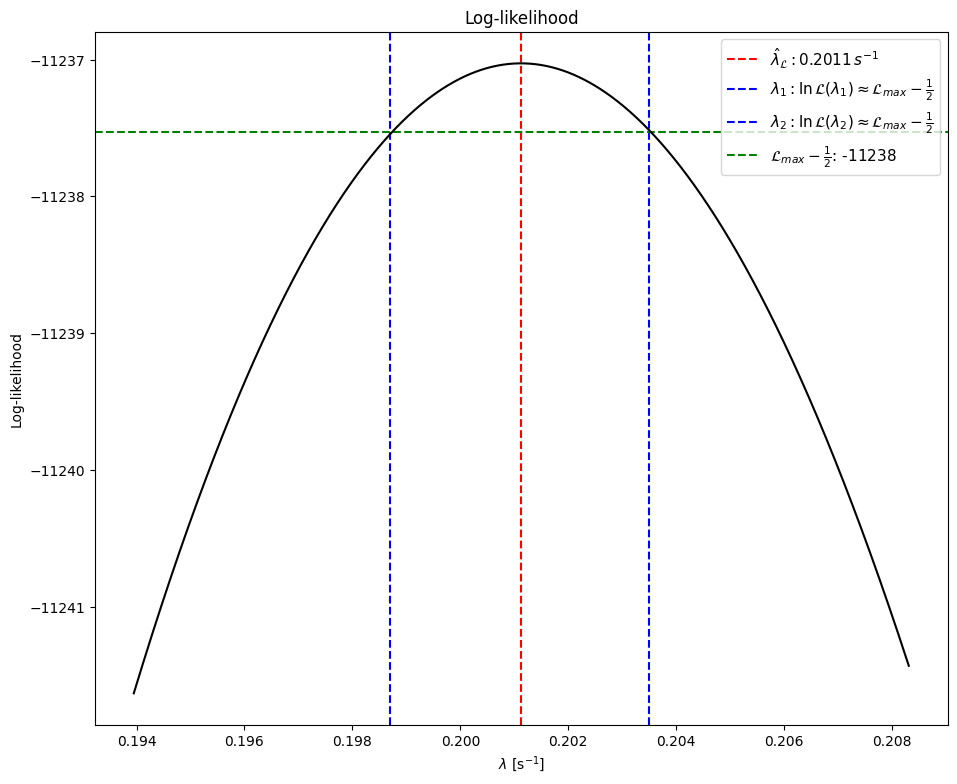

In [88]:
plt.figure(figsize=(11,9))
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=r'$\hat{\lambda}_\mathcal{L} :' + f' {max_log_likelihood:.4f}' + r' \, s^{{-1}}$')
plt.axvline(0.1987, color='blue', linestyle='--', label=r'$\lambda_1: \ln{\mathcal{L}}(\lambda_1) \approx \mathcal{L}_{max} - \frac{1}{2}$' )
plt.axvline(0.2035, color='blue', linestyle='--', label=r'$\lambda_2: \ln{\mathcal{L}}(\lambda_2) \approx \mathcal{L}_{max} - \frac{1}{2}$' )
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=r'$\mathcal{L}_{max} - \frac{1}{2}$'+ f': {valore_max - 0.5:.0f}')
plt.plot(valori_lam, val_log_likelihood, color='black')
plt.title("Log-likelihood")
plt.xlabel(r'$\lambda$ [s$^{-1}$]')
plt.ylabel("Log-likelihood")
plt.legend(loc='best', prop={'size': 11})
sigma_lam = 0.2035 - max_log_likelihood
display(Math( rf"\hat{{\sigma}}_{{\hat{{\lambda}}}} = {sigma_lam:.4f} \, s^{{-1}}" ))

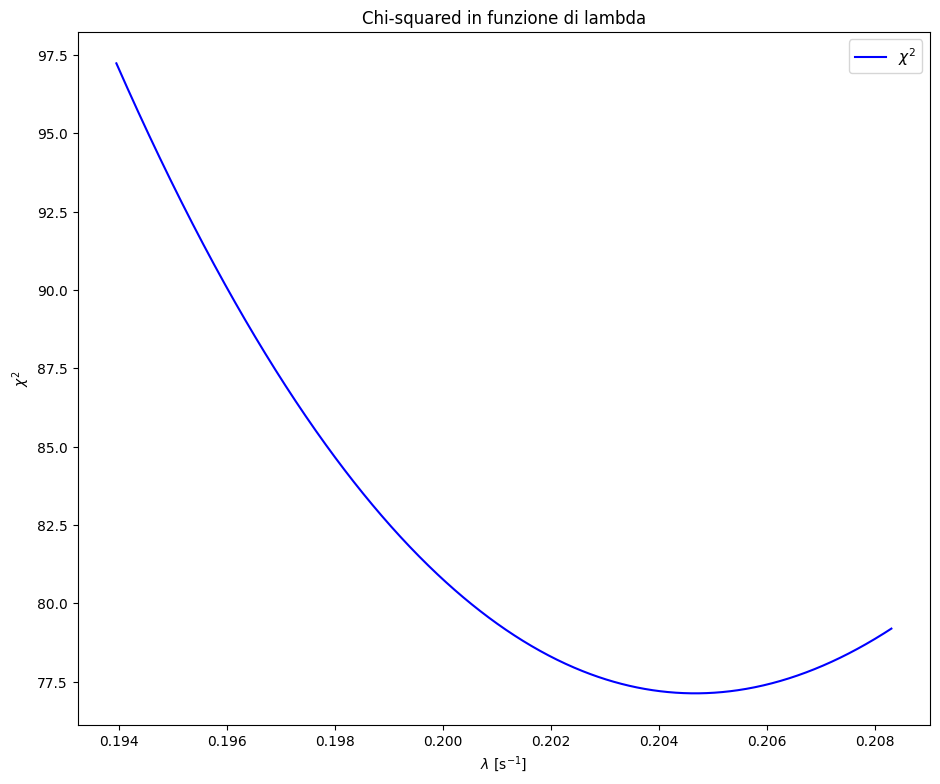

In [89]:
mask = h2 > 0
h1 = h2[mask]
centri1 = centri2[mask]
val_chi_squared = [chi_squared_binned(h1, centri1, len(risultato), lam, delta_x2) for lam in valori_lam]
plt.figure(figsize=(11,9))
plt.plot(valori_lam, val_chi_squared, color='blue', label=r'$\chi^2$')
plt.xlabel(r'$\lambda$ [s$^{-1}$]')
plt.ylabel(r'$\chi^2$')
plt.title(f'Chi-squared in funzione di lambda')
plt.legend(loc='best', prop={'size': 11})


In [90]:
for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        display(
            Math(
                rf" \lambda \text{{ che minimizza }} \chi^2 : {valori_lam[i]:.4f} \, s^{{-1}} \text{{ con valore }} \chi^2_{{\text{{min}}}} =  {val_chi_squared[i]:.4f}"
            )
        )
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

<IPython.core.display.Math object>

In [91]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        display(
            Math(
                rf"\text{{valori }} \lambda \text{{ vicino a }} \chi^2(\lambda) + 1 = {valori_lam[i]:.5f} \, s^{{-1}}"
            )
        )
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

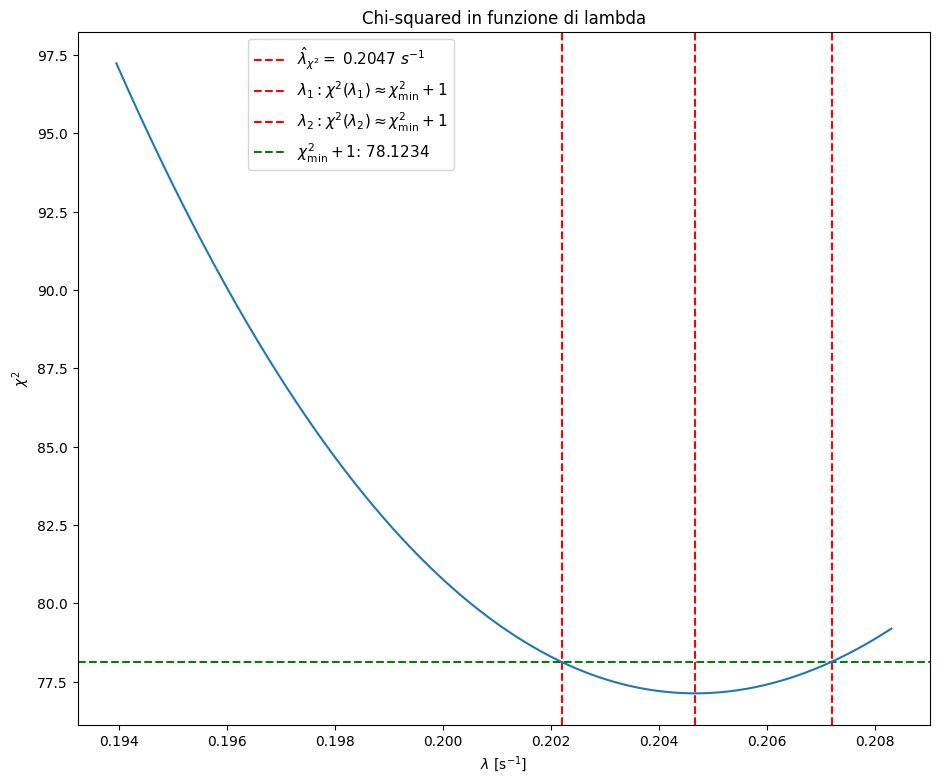

In [92]:
plt.figure(figsize=(11,9))
plt.axvline(min_chi_squared, color='red', linestyle='--', label= r'$\hat{\lambda}_{\chi^2} =$' + f' {min_chi_squared:.4f}' + r' $s^{{-1}}$')
plt.axvline(0.2022, color='red', linestyle='--', label=r'$\lambda_1: \chi^2(\lambda_1) \approx \chi^2_{\text{min}} + 1$')
plt.axvline(0.2072, color='red', linestyle='--', label=r'$\lambda_2: \chi^2(\lambda_2) \approx \chi^2_{\text{min}} + 1$')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=r'$\chi^2_{\text{min}} + 1$:' + f' {valore_min + 1:.4f}')
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared in funzione di lambda")
plt.xlabel(r"$\lambda$ [s$^{-1}$]")
plt.ylabel(r"$\chi^2$")
plt.legend(loc=(0.2, 0.8), prop={'size': 11})
sigma_lam = 0.2072 - min_chi_squared
display(Math( rf"\hat{{\sigma}}_{{\hat{{\lambda}}}} = {sigma_lam:.4f} \, s^{{-1}}" ))

In [93]:
red = valore_min / (len(h1)-2)
display(Math( rf"\chi^2_{{\text{{red}}}} = \frac{{\chi^2_{{\text{{min}}}}}}{{n - 2}} = {red:.4f} \, s^{{-1}}" ))

<IPython.core.display.Math object>

### TERZA PARTE

In [94]:
delta_t = 30
lam=lam*30

tcum = np.cumsum(dati)
tmin = 0
tmax = tcum[-1]

print(f"totale tempo trascorso {tmax}")

#creo un vettore di finestre a passi di delta_t che userò come tempo di inizio delle mie finestre temporali
w = np.arange(tmin,tmax,delta_t)
print(f"Tempo di inizio delle finestre temporali che userò: {w}")

#controllo se l'ultima finestra temporale è stata conclusa:
if (tmax<w[-1]+delta_t):
    print("Tolgo l'ultima finestra")
    w = w[:-1]

#faccio un loop sulle finestre
Poisson_counts = []

for i in w:
    #verifico se in ogni finestra ho conteggi 
    ind = np.where((tcum>=i) & (tcum<=(i+delta_t)))
    Poisson_counts.append(len(tcum[ind]))

print(f"\nI conteggi della mia Poisson sono {len(Poisson_counts)}")    

totale tempo trascorso 35116.762999999875
Tempo di inizio delle finestre temporali che userò: [0.000e+00 3.000e+01 6.000e+01 ... 3.504e+04 3.507e+04 3.510e+04]
Tolgo l'ultima finestra

I conteggi della mia Poisson sono 1170


Text(0.5, 1.0, 'Istogramma con curva di distribuzione di Poisson')

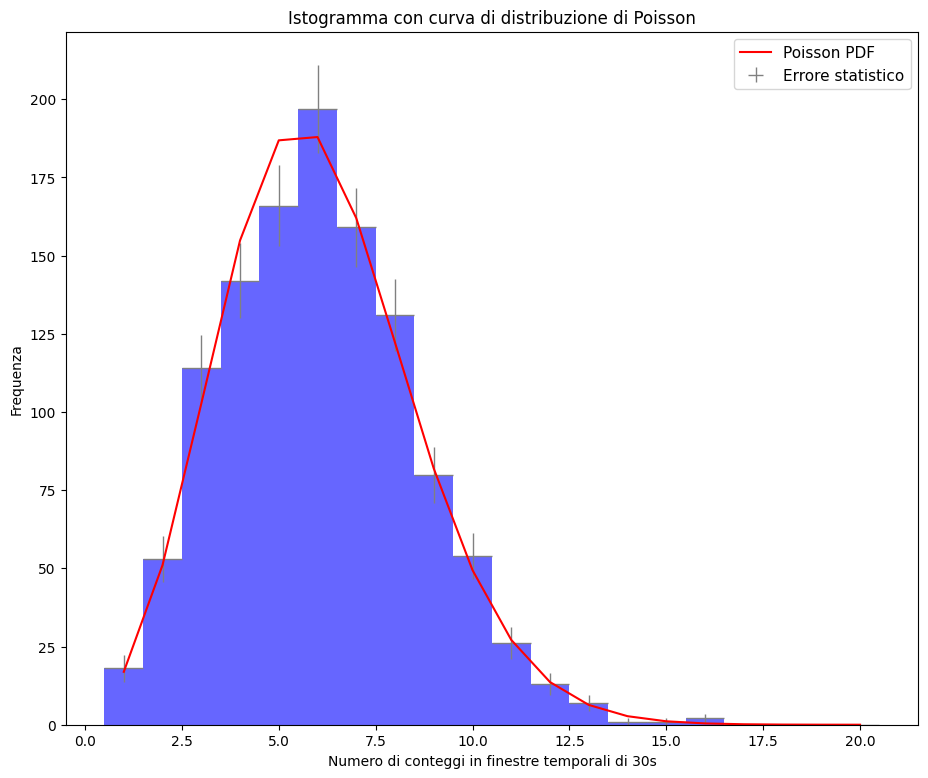

In [95]:
h, bin_edges = np.histogram(Poisson_counts, bins=20, range=(0.5,20.5))
plt.figure(figsize=(11,9))
delta_x = bin_edges[1] - bin_edges[0]
centri = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6)
plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2, fmt='none', color='grey', lw=1, label='Errore statistico')
plt.plot(centri, Poisson_pdf(lam, centri) *len(Poisson_counts)*delta_x ,color='red', label='Poisson PDF')
plt.legend(loc='best', prop={'size': 11})
plt.xlabel('Numero di conteggi in finestre temporali di 30s')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva di distribuzione di Poisson')

In [96]:
var_lam = varianza_lam * 30**2
sigma_lam = np.sqrt(var_lam)
valori_lam = np.linspace(lam-3*sigma_lam, lam + 3*sigma_lam, 1000)
val_log_likelihood = [log_likelihood_binned2(h, centri, lam) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        display(
            Math(
            rf"\lambda \hspace{{0.5em}} \text{{che massimizza}} \ln(\mathcal{{L}}) : {valori_lam[i]:.4f} \, s^{{-1}} \text{{ con valore }} \ln(\mathcal{{L}})_{{\text{{max}}}} = {val_log_likelihood[i]:.4f}"
            )
        )
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        break
    else:
        continue

<IPython.core.display.Math object>

In [97]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        display(
            Math(
                rf"\text{{valori }} \lambda \text{{ vicino a}} \ln(\mathcal{{L}}(\lambda)) - \frac{{1}}{{2}} = {valori_lam[i]:.5f} \, s^{{-1}}"
            )
        )
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

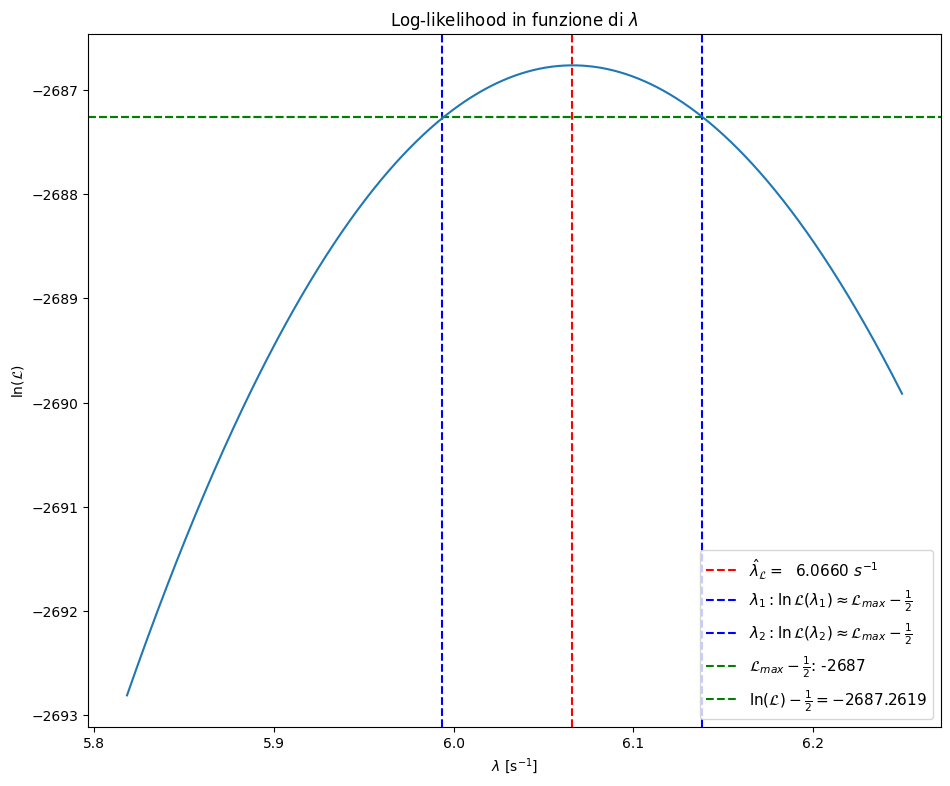

In [98]:
plt.figure(figsize=(11,9))
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=r'$\hat{\lambda}_{\mathcal{L}} =$ '+ f' {max_log_likelihood:.4f}' + r' $s^{{-1}}$')
plt.axvline(5.99355, color='blue', linestyle='--', label=r'$\lambda_1: \ln{\mathcal{L}}(\lambda_1) \approx \mathcal{L}_{max} - \frac{1}{2}$' )
plt.axvline(6.13801, color='blue', linestyle='--', label=r'$\lambda_2: \ln{\mathcal{L}}(\lambda_2) \approx \mathcal{L}_{max} - \frac{1}{2}$' )
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=r'$\mathcal{L}_{max} - \frac{1}{2}$'+ f': {valore_max - 0.5:.0f}')
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=r'$\ln(\mathcal{L}) - \frac{1}{2} =' + f'{valore_max - 0.5:.4f}$')
plt.plot(valori_lam, val_log_likelihood)
plt.title(r"Log-likelihood in funzione di $\lambda$")
plt.xlabel(r'$\lambda$ [s$^{-1}$]')
plt.ylabel(r'$\ln(\mathcal{L})$')
plt.legend(loc='best', prop={'size': 11})

sigma_lam = max_log_likelihood - 5.9936
display(Math( rf"\hat{{\sigma}}_{{\hat{{\lambda}}}} = {sigma_lam:.4f} \, s^{{-1}}" ))

In [99]:
mask= h>0
h1 = h[mask]
centri1 = centri[mask]
val_chi_squared = [chi_squared_binned2(h1, len(Poisson_counts), lam, centri1, delta_x) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        display(
            Math(
                rf" \lambda \text{{ che minimizza }} \chi^2 : {valori_lam[i]:.4f} \, s^{{-1}} \text{{ con valore }} \chi^2_{{\text{{min}}}} =  {val_chi_squared[i]:.4f}"
            )
        )
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

<IPython.core.display.Math object>

In [100]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        display(
            Math(
                rf"\text{{valori }} \lambda \text{{ vicino a }} \chi^2(\lambda) + 1 = {valori_lam[i]:.5f} \, s^{{-1}}"
            )
        )
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

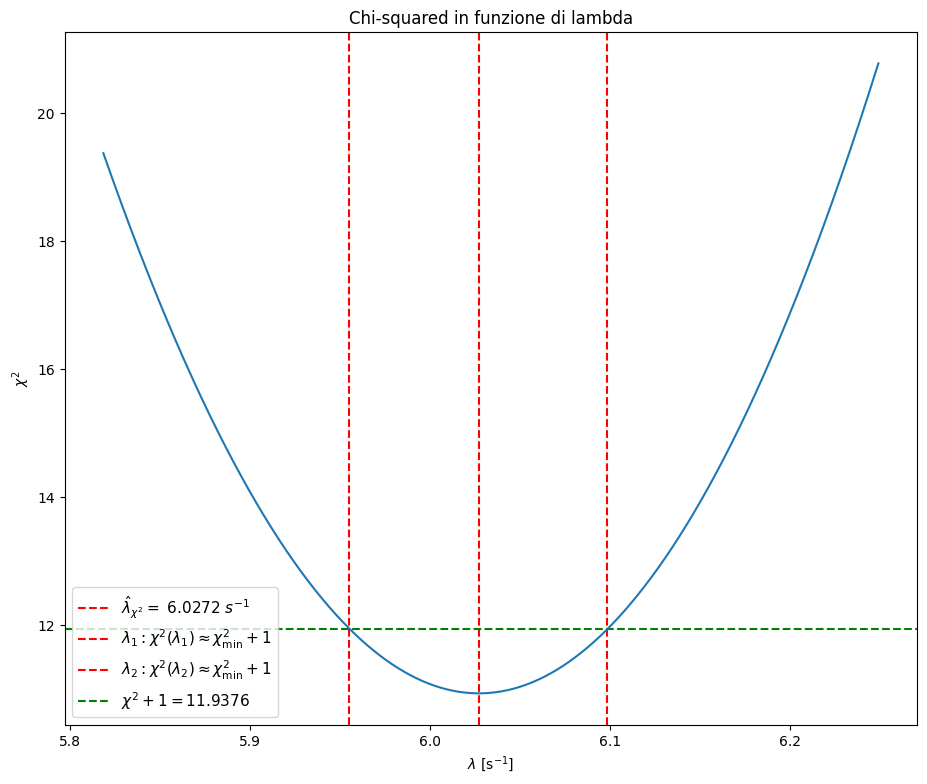

In [101]:
plt.figure(figsize=(11,9))
plt.axvline(min_chi_squared, color='red', linestyle='--', label=r'$\hat{\lambda}_{\chi^2}=$' + f' {min_chi_squared:.4f}' + r' $s^{{-1}}$')
plt.axvline(5.9552, color='red', linestyle='--', label=r'$\lambda_1: \chi^2(\lambda_1) \approx \chi^2_{\text{min}} + 1$')
plt.axvline(6.09834, color='red', linestyle='--', label=r'$\lambda_2: \chi^2(\lambda_2) \approx \chi^2_{\text{min}} + 1$')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=r'$\chi^2 + 1 =$' +f'{valore_min + 1:.4f}' )
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared in funzione di lambda")
plt.xlabel(r"$\lambda$ [s$^{-1}$]")
plt.ylabel(r"$\chi^2$")
plt.legend(loc='best', prop={'size': 11})
sigma_lam = min_chi_squared- 5.9552  
display(Math( rf"\hat{{\sigma}}_{{\hat{{\lambda}}}} = {sigma_lam:.4f} \, s^{{-1}}" ))

In [102]:
red = valore_min / (len(h1)-2)
display(Math( rf"\chi^2_{{\text{{red}}}} = \frac{{\chi^2_{{\text{{min}}}}}}{{n - 2}} = {red:.4f} \, s^{{-1}}" ))

red2=np.sqrt((2*valore_min)/(2*(len(h1)-2)-1))
display(Math(rf"\chi^2_{{\text{{red, corretto}}}} = {red2:.4f} \, s^{{-1}}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### QUARTA PARTE

In [103]:
mask = h2 > 5 
mask_2 = h > 5
h1 = h2[mask]
centri1 = centri2[mask]
h = h[mask_2]
centri = centri[mask_2]

In [104]:
val_chi = chi_squared_binned_erlang(h1, centri1, len(risultato),  0.2047 , delta_x2)

display(Math(rf"\chi^2_{{\text{{Erlang}}}} = {val_chi:.4f}"))
val_chi_poisson = chi_squared_binned_poisson(h, len(Poisson_counts), 6.0272, centri, delta_x)
display(Math(rf"\chi^2_{{\text{{Poisson}}}} = {val_chi_poisson:.4f}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [105]:
alpha = 0.05
display(Math(rf"\text{{livello di significatività}} \hspace{{0.5em}} \alpha = {alpha}"))
display(Math(r"\text{Significatività del test } \chi^2_{\text{Erlang}}"))

chi2_m1 = val_chi
ndf1 = len(h1) - 2 

display(Math(rf"\chi^2_{{\text{{min}}}} = {chi2_m1:.4f}"))
display(Math(rf"n - 2 = {ndf1}"))

p_value = chi2.sf(chi2_m1, ndf1)
display(Math(rf"p-value = {p_value:.4f}"))

if (p_value>alpha):
    display(Math(r"\text{Non posso rigettare l'ipotesi!}"))
else:
    display(Math(r"\text{Devo rigettare l'ipotesi!}"))

print("\n\n\n")

chi2_s = chi2.isf(alpha, ndf1)
display(Math(rf"\chi^2_{{\text{{soglia}}}} = {chi2_s:.4f}"))

if (chi2_m1<chi2_s):
    display(Math(r"\text{Non posso rigettare l'ipotesi!}"))
else:
    display(Math(r"\text{Devo rigettare l'ipotesi!}"))

print("\n\n\n")

display(Math(rf"\text{{Significatività dei test di chi-squared per Poisson}}"))
chi2_m2 = val_chi_poisson
ndf2 = len(h) - 2
display(Math(rf"\chi^2_{{\text{{min}}}} = {chi2_m2:.4f}"))
display(Math(rf"n - 2 = {ndf2}"))

chi2_s = chi2.isf(alpha, ndf2)
display(Math(rf"\chi^2_{{\text{{soglia}}}} = {chi2_s:.4f}"))

if (chi2_m2<chi2_s):
    display(Math(r"\text{Non posso rigettare l'ipotesi!}"))
else:
    display(Math(r"\text{Devo rigettare l'ipotesi!}"))

print("\n\n\n")


p_value = chi2.sf(chi2_m2, ndf2)
display(Math(rf"p-value = {p_value:.4f}"))

if (p_value>alpha):
    display(Math(r"\text{Non posso rigettare l'ipotesi!}")) 
else:
    display(Math(r"\text{Devo rigettare l'ipotesi!}"))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### RIASSUNTO DEI RISULTATI


- Stima ML del tempo medio di attesa  
    $\hat{\tau}_{\mathcal{L}} = 4.97 \pm 0.06 \ \mathrm{s}$  
    $\sigma^2_{\hat{\tau}_{\mathcal{L}}} = 0.00350\ \mathrm{s}^2$

- Distribuzione di Erlang (tempo di attesa fra 2 eventi)  
    $\hat{\lambda} = \dfrac{1}{\hat{\tau}} = 0.2011 \pm 0.0024\ \mathrm{s^{-1}}$  
    $\mathrm{Var}(\hat{\lambda}) = 5.7274\cdot 10^{-6}$

- Stima tramite test di Pearson per Erlang  
    $\chi^2_{\text{Erlang}} = 71.7646$ con $n-2 = 57$ (gradi di libertà)  
    $p\text{-value} = 0.8311 \quad\Rightarrow\ $ Non si rifiuta l'ipotesi Erlang  
    $\chi^2_{\text{red}} = 0.7813$ (e $\chi^2_{\text{red, corretto}} = 0.9001$)

- Distribuzione di Poisson (conteggi in finestre da 30 s)  
    $\Delta t = 30\ \mathrm{s}$, stima $\hat{\lambda}_{30s} = 6.0339 \pm 0.0720$ (per 30 s)  
    $\mathrm{Var}(\hat{\lambda}_{30s}) = 0.00515469$

- Stima tramite test di Pearson per Poisson  
    $\chi^2_{\text{Poisson}} = 6.5924$ con $n-2 = 11$ (gradi di libertà)  
    (soglia/valori calcolati a livello $\alpha=0.05$) $\;\Rightarrow\ $ Non si rifiuta l'ipotesi Poisson

- Conclusione sintetica: le stime ML e i test di $\chi^2$ non forniscono evidenza sufficiente per rigettare i modelli Erlang (tempi fra 2 eventi) e Poisson (conteggi in 30 s) alle condizioni di significatività scelte.

### RISPOSTA ALLE DOMANDE

La distribuzione di Erlang riporta la densità di probabilità che avvengo 2 eventi consecutivi in un tempo t (variabile continua), la distribuzione di Poisson riporta la densità di probabilità che un certo numero di eventi si verifichi all'interno della finestra temporale di 30s (variabile discreta).